# 03 · UKF State Estimation
The **Unscented Kalman Filter** estimates the full 8-state vector from only
4 noisy measurements: `[x, θ₁, θ₂, θ₃]` (positions, no velocities).

The LQR controller is then driven by the **estimated** state x̂ (output feedback),
mirroring `matlab/ukf_design.m`.

In [1]:
# Install packages into whichever Python kernel VS Code is using
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "matplotlib", "numpy", "scipy", "pandas",
    "gymnasium", "stable-baselines3", "filterpy"
], check=True)
print('packages ready')

packages ready


In [2]:
import sys, os

# Project root (python/)
_nb_dir = os.path.abspath("")
_py_dir = _nb_dir if os.path.basename(_nb_dir) != "notebooks" else os.path.dirname(_nb_dir)
if _py_dir not in sys.path:
    sys.path.insert(0, _py_dir)

# Inject venv packages so the notebook works regardless of which kernel VS Code picks
_venv_sp = os.path.join(_py_dir, "venv", "Lib", "site-packages")
if os.path.exists(_venv_sp) and _venv_sp not in sys.path:
    sys.path.insert(0, _venv_sp)

print("Python :", sys.executable)
print("Project:", _py_dir)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

Python : c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\.venv\Scripts\python.exe
Project: c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\python
numpy 2.5.1 | matplotlib 3.11.0


In [3]:
from utils.dynamics import get_linear_system
from controllers.lqr import LQRController
from estimation.ukf import build_pendulum_ukf, P0_DEFAULT, Q_DEFAULT, R_DEFAULT
from scipy.signal import StateSpace

Ts  = 0.01   # 100 Hz — matches ukf_design.m
rng = np.random.default_rng(42)

lqr     = LQRController()
ukf, C_meas = build_pendulum_ukf(Ts=Ts)

# Discretise for true-plant propagation
A, B, _, _ = get_linear_system()
sys_d = StateSpace(A, B, np.eye(8), np.zeros((8,1))).to_discrete(Ts, method="zoh")
Ad, Bd = sys_d.A, sys_d.B.flatten()

print("UKF configured — observing [x, θ₁, θ₂, θ₃] only.")
print(f"Process noise Q diagonal: {np.diag(Q_DEFAULT)}")
print(f"Sensor  noise R diagonal: {np.diag(R_DEFAULT)}")

UKF configured — observing [x, θ₁, θ₂, θ₃] only.
Process noise Q diagonal: [1.e-06 1.e-04 1.e-06 1.e-04 1.e-06 1.e-04 1.e-06 1.e-04]
Sensor  noise R diagonal: [1.e-04 5.e-05 5.e-05 5.e-05]


## Simulation

In [4]:
# Initial conditions (matching ukf_design.m)
x0     = np.array([0, 0, np.deg2rad(3), 0, np.deg2rad(2), 0, np.deg2rad(1), 0])
x_hat0 = x0 + [0.01, 0, np.deg2rad(0.5), 0, np.deg2rad(0.3), 0, np.deg2rad(0.2), 0]
ukf.reset(x_hat0, P0_DEFAULT)

N = 500   # 5 s at 100 Hz
X_true = np.zeros((N+1, 8));  X_true[0] = x0
X_hat  = np.zeros((N+1, 8));  X_hat[0]  = x_hat0

for k in range(N):
    u = -lqr.K @ ukf.x_hat

    w = rng.multivariate_normal(np.zeros(8), Q_DEFAULT)
    X_true[k+1] = Ad @ X_true[k] + Bd * u + w

    v = rng.multivariate_normal(np.zeros(4), R_DEFAULT)
    y = C_meas @ X_true[k+1] + v

    X_hat[k+1] = ukf.step(u, y)

t = np.arange(N+1) * Ts
print("Simulation complete.")
errors = np.linalg.norm(X_true - X_hat, axis=1)
print(f"Mean estimation error: {errors.mean():.5f}   Max: {errors.max():.5f}")

Simulation complete.
Mean estimation error: 0.07419   Max: 0.14147


## True vs Estimated State

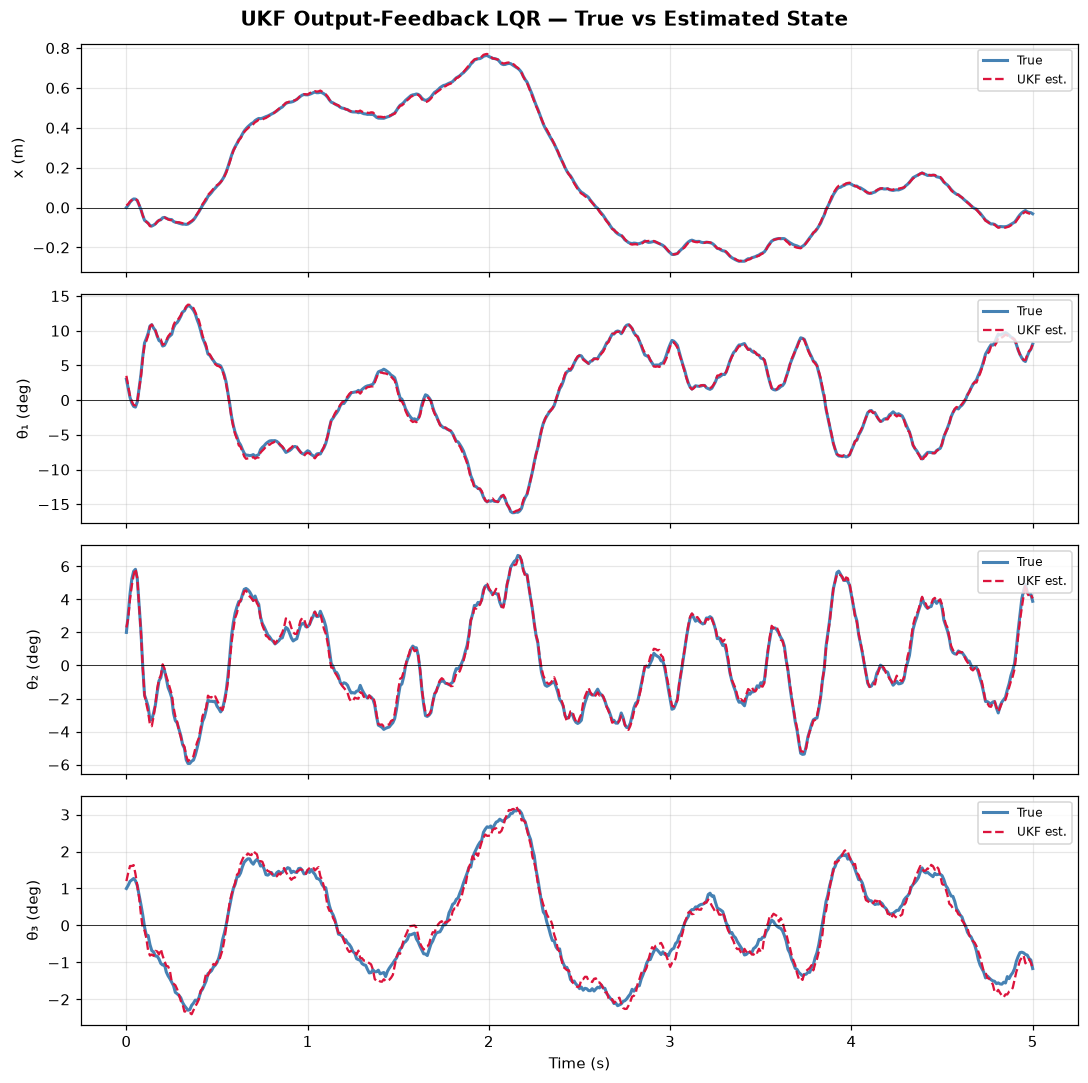

In [5]:
labels = [("x (m)", 0, 1.0), ("θ₁ (deg)", 2, 180/np.pi),
          ("θ₂ (deg)", 4, 180/np.pi), ("θ₃ (deg)", 6, 180/np.pi)]

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
for ax, (lbl, idx, scale) in zip(axes, labels):
    ax.plot(t, X_true[:, idx]*scale, label="True",     color="steelblue", lw=2)
    ax.plot(t, X_hat[:,  idx]*scale, label="UKF est.", color="crimson",   lw=1.5, ls="--")
    ax.set_ylabel(lbl); ax.legend(loc="upper right", fontsize=8)
    ax.axhline(0, color="k", lw=0.5)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("UKF Output-Feedback LQR — True vs Estimated State", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../results/python/ukf_estimation.png", dpi=150, bbox_inches="tight")
plt.show()

## Estimation Error

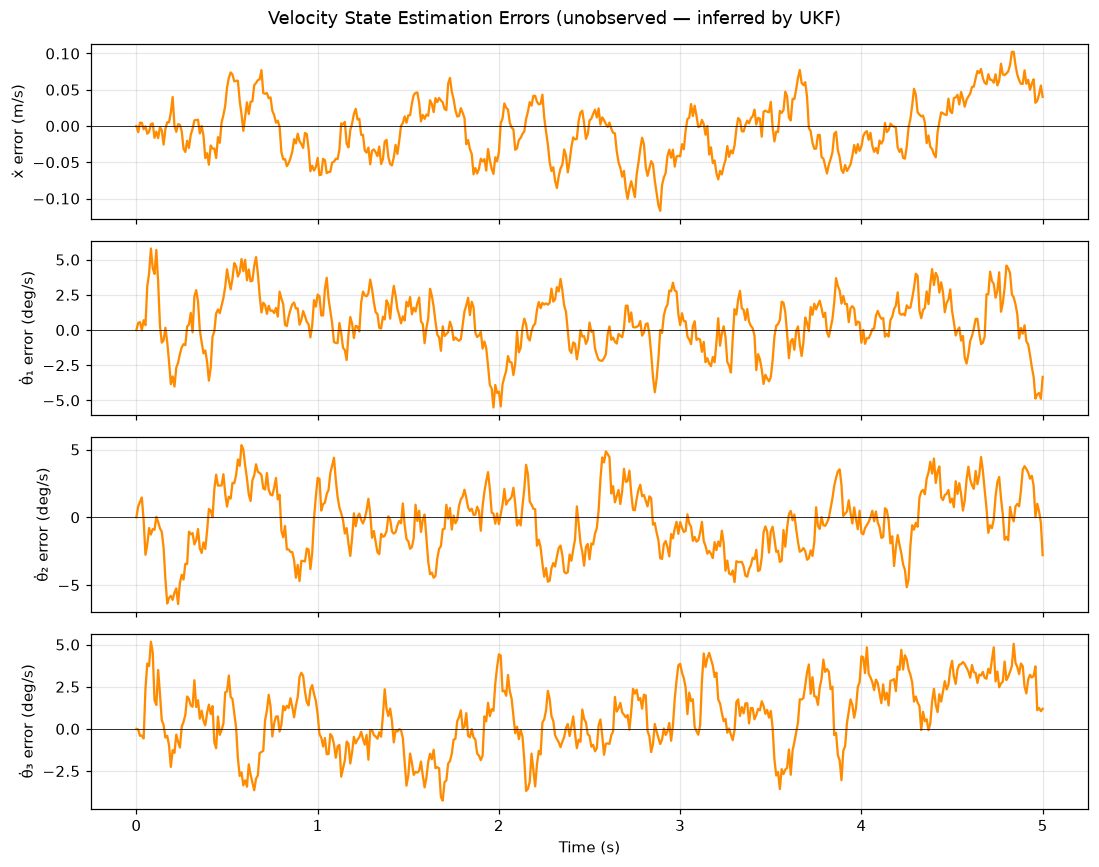


The UKF accurately reconstructs velocities from position-only measurements.


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
vel_labels = [("ẋ error (m/s)", 1, 1.0), ("θ̇₁ error (deg/s)", 3, 180/np.pi),
              ("θ̇₂ error (deg/s)", 5, 180/np.pi), ("θ̇₃ error (deg/s)", 7, 180/np.pi)]

for ax, (lbl, idx, scale) in zip(axes, vel_labels):
    err = (X_true[:, idx] - X_hat[:, idx]) * scale
    ax.plot(t, err, color="darkorange", lw=1.5)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(lbl)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Velocity State Estimation Errors (unobserved — inferred by UKF)", fontsize=12)
plt.tight_layout(); plt.show()
print("\nThe UKF accurately reconstructs velocities from position-only measurements.")